 🏥  Medical Insurance Cost Prediction using Machine Learning

## 📘 Problem Statement
The goal of this project is to predict **individual medical insurance costs** based on personal and lifestyle attributes such as age, gender, BMI, smoking habits, and region.  
Accurate prediction of healthcare costs can assist insurance companies in risk assessment and help individuals understand how different factors impact their medical expenses.

---

## 📊 Dataset Overview
The dataset contains demographic and lifestyle information of insured individuals along with their **annual medical charges**.

**Source:** https://www.kaggle.com/datasets/rahulvyasm/medical-insurance-cost-prediction
---

## 🧩 Features Description

| Feature | Type | Description |
|:---------|:------|:-------------|
| `age` | Numeric | Age of the individual |
| `sex` | Categorical | Gender of the individual (`male`, `female`) |
| `bmi` | Numeric | Body Mass Index — a measure of body fat based on height and weight |
| `children` | Numeric | Number of children/dependents covered by insurance |
| `smoker` | Categorical | Smoking status (`yes`, `no`) |
| `region` | Categorical | Residential region in the U.S. (`northeast`, `northwest`, `southeast`, `southwest`) |
| `charges` | Numeric (Target) | Individual medical insurance cost (in USD) |

---

## 🎯 Objective
Build and evaluate regression models using **Scikit-Learn** to predict the `charges` value based on the input features.  
The workflow includes:
- Data loading & exploration  
- Preprocessing & encoding  
- Feature scaling  
- Model training & evaluation  
- Model deployment


# 1 Loading Dataset

In [52]:
import numpy as np
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt

print("Seaborn installed successfully!")
df = pd.read_csv("medical_insurance.csv")
df.head()

Seaborn installed successfully!


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


# 2 Dataset Exploration 


In [53]:
df.shape

(2772, 7)

In [54]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

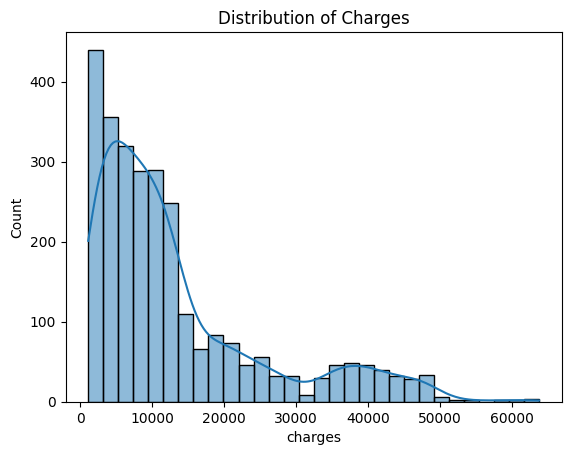

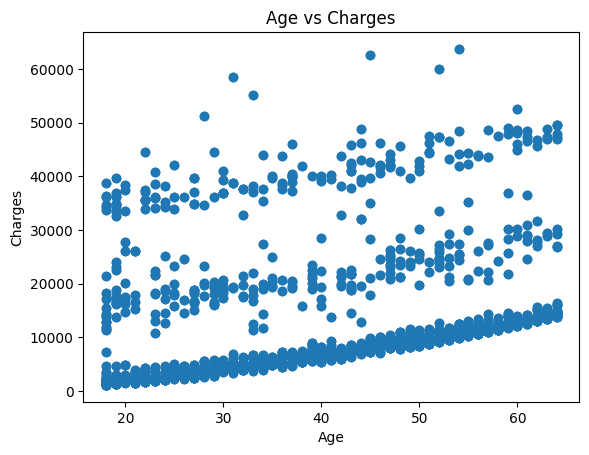

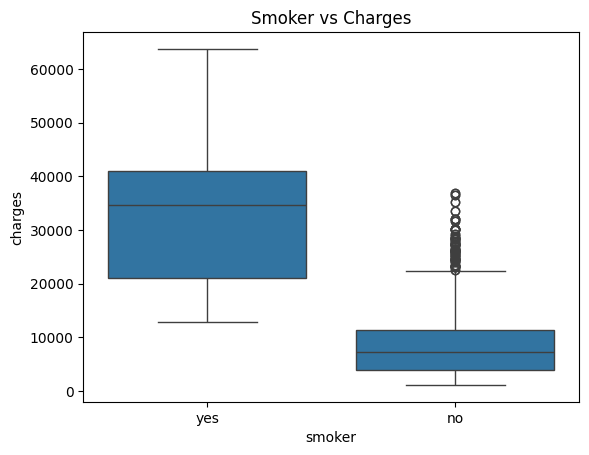

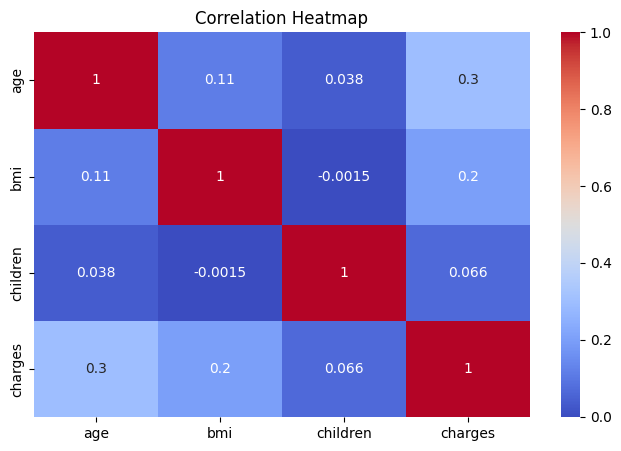

In [ ]:
# EDA
sns.histplot(df['charges'], bins=30, kde=True)
plt.title("Distribution of Charges")
plt.show()


plt.scatter(df['age'], df['charges'])
plt.title("Age vs Charges")
plt.xlabel("Age")
plt.ylabel("Charges")
plt.show()



sns.boxplot(x='smoker', y='charges', data=df)
plt.title("Smoker vs Charges")
plt.show()


plt.figure(figsize=(8,5))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

## 🔠 Encoding Categorical Features

Before training regression models, categorical variables must be converted into numeric format, since machine learning algorithms in Scikit-Learn work with numerical data only.

### 1. Encoding `smoker`
- The `smoker` column contains two categories: `yes` and `no`.
- It can be converted into a binary numeric variable:
  - `yes` → `1`
  - `no` → `0`

Example:
| smoker | smoker_encoded |
|:-------|:----------------|
| yes | 1 |
| no | 0 |

### 2. Encoding `region`
- The `region` column has **four categories**: `northeast`, `northwest`, `southeast`, and `southwest`.
- We will use **One-Hot Encoding** to create separate binary columns for each region.

Example:
| region | northeast | northwest | southeast | southwest |
|:--------|:-----------|:-----------|:-----------|:-----------|
| northwest | 0 | 1 | 0 | 0 |
| southeast | 0 | 0 | 1 | 0 |

> ✅ After encoding, all features will be in numeric form and ready for model training.


In [56]:
df['region'].value_counts()

region
southeast    766
southwest    684
northwest    664
northeast    658
Name: count, dtype: int64

In [57]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(sparse_output=False)

encoded = encoder.fit_transform(df[['region']])

df[encoder.get_feature_names_out(['region'])] = encoded

df.drop('region', axis=1, inplace=True)

print(df.head())
df['sex'] = df['sex'].map({'male':1, 'female':0})
df['smoker'] = df['smoker'].map({"yes":1,'no':0})
df.head()


   age     sex     bmi  children smoker      charges  region_northeast  \
0   19  female  27.900         0    yes  16884.92400               0.0   
1   18    male  33.770         1     no   1725.55230               0.0   
2   28    male  33.000         3     no   4449.46200               0.0   
3   33    male  22.705         0     no  21984.47061               0.0   
4   32    male  28.880         0     no   3866.85520               0.0   

   region_northwest  region_southeast  region_southwest  
0               0.0               0.0               1.0  
1               0.0               1.0               0.0  
2               0.0               1.0               0.0  
3               1.0               0.0               0.0  
4               1.0               0.0               0.0  


,age,sex,bmi,children,smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest
0,19,0,27.900,0,1,16884.92400,0.0,0.0,0.0,1.0
1,18,1,33.770,1,0,1725.55230,0.0,0.0,1.0,0.0
2,28,1,33.000,3,0,4449.46200,0.0,0.0,1.0,0.0
3,33,1,22.705,0,0,21984.47061,0.0,1.0,0.0,0.0
4,32,1,28.880,0,0,3866.85520,0.0,1.0,0.0,0.0


## ⚖️ Feature Scaling

After encoding categorical variables, we apply **feature scaling** to ensure that all numeric features are on a similar scale.  
This helps regression models (especially distance-based or gradient-based models) perform better and converge faster.

### Why Scaling is Important
- Features like `age`, `bmi`, and `charges` have different value ranges.
- Models such as **Linear Regression**, **SVR**, and **KNN** are sensitive to feature magnitudes.
- Scaling ensures that no single feature dominates the learning process.

### Common Scaling Techniques
1. **Standardization (StandardScaler)**
   - Transforms data so it has a **mean = 0** and **standard deviation = 1**.
   - Formula:  
     \[
     z = \frac{x - \mu}{\sigma}
     \]
   - Works well for most regression models.

2. **Normalization (MinMaxScaler)**
   - Scales all values between **0 and 1**.
   - Useful when features have different units or ranges.

### Applied in this Project
We will use **`StandardScaler`** from Scikit-Learn to standardize the numeric columns:
- `age`
- `bmi`
- `children`

> ⚠️ Note: The target variable `charges` is **not scaled**, since it is the value we want to predict.


In [58]:
features = ['age','bmi','children']

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df[features] = scaler.fit_transform(df[features])

df.head()

,age,sex,bmi,children,smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest
0,-1.428353,0,-0.457114,-0.907084,1,16884.92400,0.0,0.0,0.0,1.0
1,-1.499381,1,0.500731,-0.083758,0,1725.55230,0.0,0.0,1.0,0.0
2,-0.789099,1,0.375085,1.562893,0,4449.46200,0.0,0.0,1.0,0.0
3,-0.433959,1,-1.304814,-0.907084,0,21984.47061,0.0,1.0,0.0,0.0
4,-0.504987,1,-0.297201,-0.907084,0,3866.85520,0.0,1.0,0.0,0.0


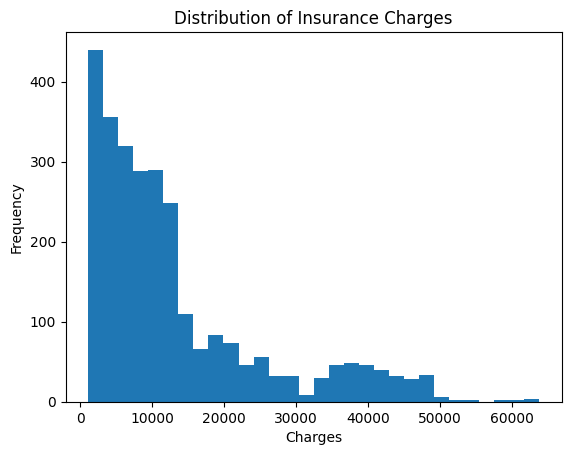

In [59]:
plt.hist(df['charges'], bins=30)
plt.title("Distribution of Insurance Charges")
plt.xlabel("Charges")
plt.ylabel("Frequency")
plt.show()

# Train Test Split

In [60]:
from sklearn.model_selection import train_test_split

X = df.drop("charges",axis=1)
y = df['charges']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

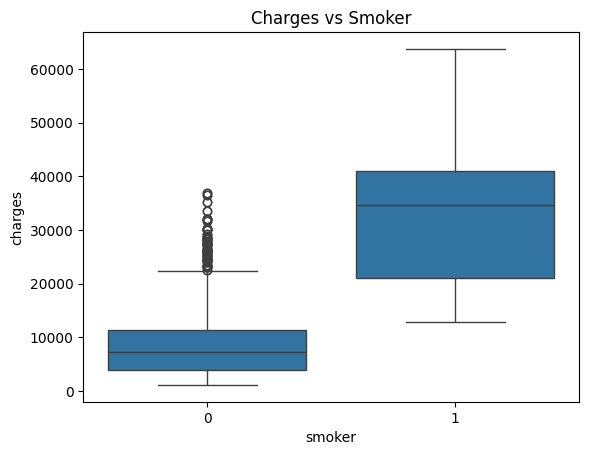

In [61]:
sns.boxplot(x='smoker', y='charges', data=df)
plt.title("Charges vs Smoker")
plt.show()

# 3 Model Training and Evaluation

### 3.1 Linear Regression

In [62]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error


lr_model = LinearRegression()

lr_model.fit(X_train,y_train)

y_pred = lr_model.predict(X_test)

print("r2 score :", r2_score(y_test, y_pred))
print("MSE :", mean_squared_error(y_test, y_pred))

r2 score : 0.7398166177564298
MSE : 39933194.54805149


### 3.2 Random Forest Regressor

In [63]:
from sklearn.ensemble import RandomForestRegressor


rf_model = RandomForestRegressor()

rf_model.fit(X_train,y_train)

y_pred = rf_model.predict(X_test)

print("r2 score :", r2_score(y_test, y_pred))
mse=mean_squared_error(y_test, y_pred)
print("MSE :", mean_squared_error(y_test, y_pred))
print("rmse:", np.sqrt(mse))


r2 score : 0.9528118584481993
MSE : 7242481.132730455
rmse: 2691.1858227797006


### 3.4 Save Models

In [64]:
import pickle 

pickle.dump(rf_model,open("rf_model.pkl",'wb'))
pickle.dump(scaler,open("scaler.pkl",'wb'))

# 5 Inference

In [78]:
import numpy as np 

rf_model.predict(np.array([df.iloc[10,:-1]]))[0]


c:\Users\ziyad\Desktop\itt\Medical-Insurance-Cost-Predictor-main\medical\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


np.float64(2983.6365785999933)

In [79]:
df.iloc[10]['charges']

np.float64(2721.3208)

In [ ]:
df.iloc[50]['charges']

np.float64(2211.13075)

In [66]:
rf_model.predict(np.array([df.iloc[50,:-1]]))[0]

c:\Users\ziyad\Desktop\itt\Medical-Insurance-Cost-Predictor-main\medical\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


np.float64(2184.793523000002)

In [67]:
rf_model.predict(np.array([df.iloc[150,:-1]]))[0]

c:\Users\ziyad\Desktop\itt\Medical-Insurance-Cost-Predictor-main\medical\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


np.float64(7238.213400699996)

In [81]:
df.iloc[150]['charges']

np.float64(5125.2157)